# Bulk + single-cell DNA-seq coverage model (F4 / F5 demo)

Per-module deep-dive for the **DNA assay** (`src/iscc/data/{assay,batch,dna}.py`,
DESIGN_features §C C1 / §D, milestones **F4** (bulk) + **F5** (single-cell)). It starts from a
realistic upstream input — a tumour **biopsy / sample** — and **sweeps the key parameters**
(*capture breadth* WGS / WES / panel × *bulk vs single-cell* × *depth* × *copy number*),
visualising their effect on **coverage / VAF / CNA log-ratio** profiles while keeping the
**ground truth (true CN, true SNVs, clone)** surfaced so each effect is interpretable.

**The shared core.** Bulk and single-cell are two *regimes* of one model (`batch.DNABatch`):

| | depth model | allele model | amplification regime |
|---|---|---|---|
| **bulk** | Dirichlet-Multinomial, **large $\kappa$** (≈ multinomial/Poisson) | Binomial | un-amplified pool |
| **single-cell** | Dirichlet-Multinomial, **small $\kappa$** (lumpy) | Beta-Binomial **+ ADO** | per-cell MDA/MALBAC |

* **Depth** = a fixed read budget $N$ partitioned across loci with $p_\text{seg} \propto
  \text{CN}_\text{seg}\cdot\text{length}\cdot(\text{GC/mappability})$, $p\sim\text{Dir}(\kappa\bar p)$.
  Copy number drives coverage; at fixed $N$ an amplicon compositionally *steals* reads from the rest.
* **Allele / VAF** is a separate layer: bulk $\text{Binomial}(\text{depth}, \text{true alt frac})$;
  single-cell $\text{Beta-Binomial}$ + an explicit **ADO** Bernoulli (one allele lost at a locus).
* **Capture breadth** (orthogonal, both modalities) sets the observed locus set, the depth regime,
  and a systematic per-target/amplicon capture-efficiency mean.

The knobs $\kappa$, the per-target/amplicon capture efficiencies, and the ADO rate are the
**M4 `estimate()` targets** (DESIGN_inference).

In [1]:
%matplotlib inline
import os, sys, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from iscc.data.dna import bulkDNA, scDNA, run_dna_batches, genome_features, DNA_BREADTH_PRESETS
from iscc.data.batch import DNABatchHyperParams

np.random.seed(0)
NB_DIR = os.getcwd()
OUT = os.path.join(NB_DIR, "example_out")
# Reuse the shared example pipeline (tumour -> sample) the other demos build.
if not os.path.isdir(os.path.join(OUT, "sample", "cell_data")):
    subprocess.run([sys.executable, os.path.join(NB_DIR, "generate_example.py")], check=True)

print("capture-breadth presets (depth regime + capture bias + locus selection):")
pd.DataFrame(DNA_BREADTH_PRESETS).T

capture-breadth presets (depth regime + capture bias + locus selection):


,mu_depth,capture_sigma,gc_curve_sigma,locus_frac,panel_size
wgs,30.0,0.00,0.20,1.0,NaN
wes,120.0,0.30,0.12,0.3,NaN
panel,1500.0,0.45,0.05,NaN,30.0


## 1. The biopsy / sample + its copy-number ground truth (upstream input)

We load the sampled `cell_data` (output of `isccsample`) for the **biology**: the per-cell
**clone** labels and coordinates, the real index of cells.

This particular example biopsy is diploid, so to *demonstrate* the copy-number model we overlay a
transparent **clone-specific CNA + SNV ground truth** — each clone carries a distinct segmental
amplification / loss and a couple of heterozygous driver SNVs. In a full pipeline run these come
straight from the engine's per-cell `seg_cns` (`cell_cnv`) and `cell_snv` (VAF); assigning them
here just gives us an *exact* ground truth to validate coverage / VAF recovery against.

In [2]:
# --- load the real sample's biology -------------------------------------------------
from iscc.data.main import load_cell_data
sample = load_cell_data(os.path.join(OUT, "sample"))
clone = sample["cell_type"].iloc[:, 0].astype(str)
genes = list(sample["cell_snv"].columns)
cells = list(sample["cell_snv"].index)
seg_of = np.array([int(g.split("_")[1]) for g in genes])
n_seg = seg_of.max() + 1
clones = sorted(clone.unique())
print(f"{len(cells)} cells, {len(genes)} loci, {n_seg} segments, {len(clones)} clones: {clones}")

# --- overlay a clone-specific copy-number + SNV ground truth ------------------------
rng = np.random.default_rng(0)
# each clone gets a per-segment CN profile (diploid baseline 2, a few amps/losses)
clone_cn = {}
for k, cl in enumerate(clones):
    prof = np.full(n_seg, 2)
    prof[(k) % n_seg] = 8        # a clone-specific amplification
    prof[(k + 1) % n_seg] = 6
    prof[(k + 2) % n_seg] = 1    # a single-copy loss
    clone_cn[cl] = prof
cnv = np.vstack([clone_cn[clone[c]][seg_of] for c in cells]).astype(float)

# a heterozygous (VAF 0.5) driver SNV present in all cells, in a baseline-diploid segment
af = np.zeros((len(cells), len(genes)))
het_dip = 3                       # locus index of the het SNV (segment 0)
af[:, het_dip] = 0.5

cell_data = {
    "cell_cnv": pd.DataFrame(cnv, index=cells, columns=genes),
    "cell_snv": pd.DataFrame(af, index=cells, columns=genes),
    "cell_type": sample["cell_type"],
    "cell_crd": sample.get("cell_crd"),
}

# show the injected ground-truth CN profile per clone x segment
gt_cn = pd.DataFrame({cl: clone_cn[cl] for cl in clones}, index=[f"seg{ s}" for s in range(n_seg)])
print("ground-truth copy number (clone x segment):")
gt_cn

494 cells, 200 loci, 5 segments, 4 clones: ['5889025184', '5889026912', 'epithelial', 'stromal']
ground-truth copy number (clone x segment):


,5889025184,5889026912,epithelial,stromal
seg0,8,2,2,1
seg1,6,8,2,2
seg2,1,6,8,2
seg3,2,1,6,8
seg4,2,2,1,6


## 2. Bulk DNA across capture breadth — coverage tracks copy number

The headline F4 behaviour: **per-locus coverage is proportional to copy number**. We run bulk
DNA at each breadth and plot the per-locus coverage (and the CNA **log2-ratio**, what a caller
consumes) against the true copy number. Pooling all sampled cells, the true CN at a locus is the
mean copy number across the pool.

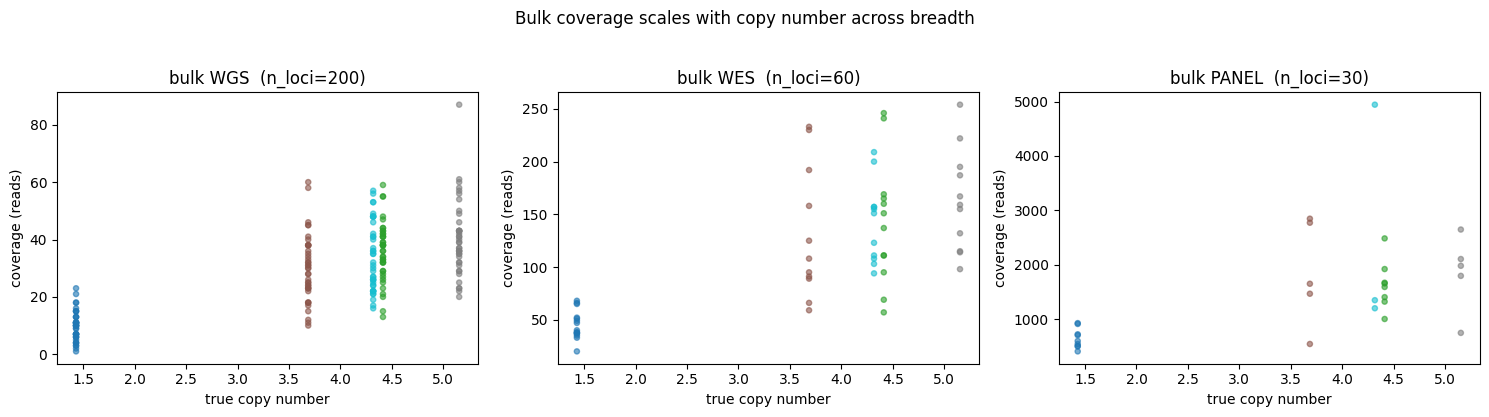

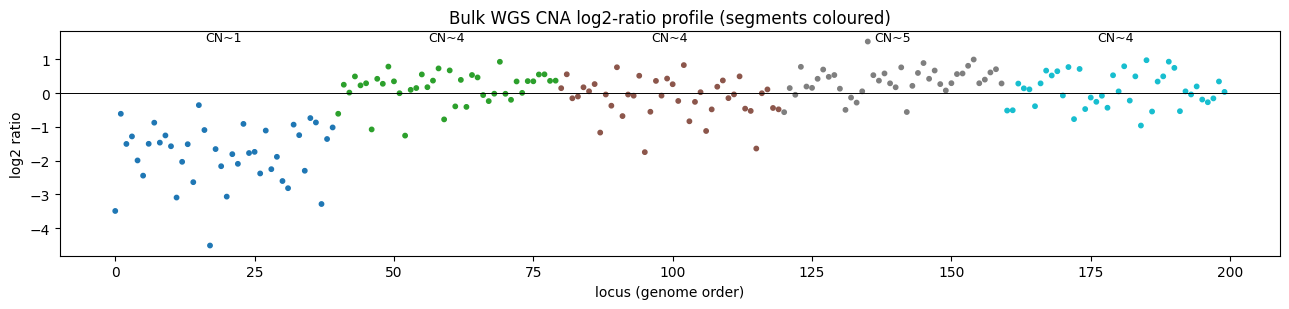

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
bulk_runs = {}
for ax, breadth in zip(axes, ["wgs", "wes", "panel"]):
    b = bulkDNA(breadth=breadth, seed=1).run(cell_data)
    bulk_runs[breadth] = b
    od = b.observed_data
    ax.scatter(od["true_cn"], od["coverage"], s=14, alpha=0.6,
               c=od["segment"], cmap="tab10")
    ax.set_title(f"bulk {breadth.upper()}  (n_loci={len(od)})")
    ax.set_xlabel("true copy number"); ax.set_ylabel("coverage (reads)")
fig.suptitle("Bulk coverage scales with copy number across breadth", y=1.03)
plt.tight_layout(); plt.show()

# CNA log2-ratio profile along the genome (WGS) -- this is the CNA-caller input
od = bulk_runs["wgs"].observed_data
fig, ax = plt.subplots(figsize=(13, 3.2))
ax.scatter(range(len(od)), od["log2_ratio"], s=10, c=od["segment"], cmap="tab10")
ax.axhline(0, color="k", lw=0.7)
for s in range(n_seg):
    xs = np.where(od["segment"].values == s)[0]
    if len(xs):
        ax.text(xs.mean(), ax.get_ylim()[1]*0.85, f"CN~{od['true_cn'][od.segment==s].mean():.0f}",
                ha="center", fontsize=9)
ax.set_title("Bulk WGS CNA log2-ratio profile (segments coloured)")
ax.set_xlabel("locus (genome order)"); ax.set_ylabel("log2 ratio")
plt.tight_layout(); plt.show()

## 3. Compositional read-stealing (the DM coupling)

Because the depth model spends a **fixed budget**, a large amplicon does not just gain coverage —
it **reduces** coverage everywhere else. This compositional coupling (the reason depth is *relative*,
not absolute) is exactly what per-bin NB models miss and what a WGD / high-ploidy genome looks like
to a caller. We hold the read budget fixed and compare a diploid genome to one with a strong amplicon.

In [4]:
# same biology except segment 0 is strongly amplified in one case
import copy
base = copy.deepcopy(cell_data)
amped = copy.deepcopy(cell_data)
amped["cell_cnv"] = amped["cell_cnv"].copy()
amped["cell_cnv"].iloc[:, seg_of == 0] = 40        # massive amplification on seg 0

N = 300000
od_base = bulkDNA(breadth="wgs", seed=5, n_reads=N).run(base).observed_data
od_amp  = bulkDNA(breadth="wgs", seed=5, n_reads=N).run(amped).observed_data
other = od_base["segment"].values != 0
print(f"total reads spent: base={od_base.coverage.sum()}, amplified={od_amp.coverage.sum()} (fixed budget)")
print(f"mean coverage on the OTHER segments: base={od_base.coverage.values[other].mean():.1f} "
      f"-> amplified={od_amp.coverage.values[other].mean():.1f}  "
      f"({100*(1-od_amp.coverage.values[other].mean()/od_base.coverage.values[other].mean()):.0f}% lost to the amplicon)")

total reads spent: base=300000, amplified=300000 (fixed budget)
mean coverage on the OTHER segments: base=1758.6 -> amplified=609.7  (65% lost to the amplicon)


## 4. VAF recovers the true alt fraction at high depth

The allele layer is a separate Binomial draw. At a heterozygous locus (true alt fraction 0.5),
the observed VAF concentrates on the truth as depth grows — and panel breadth (very deep) gives a
tight estimate while shallow WGS is noisy.

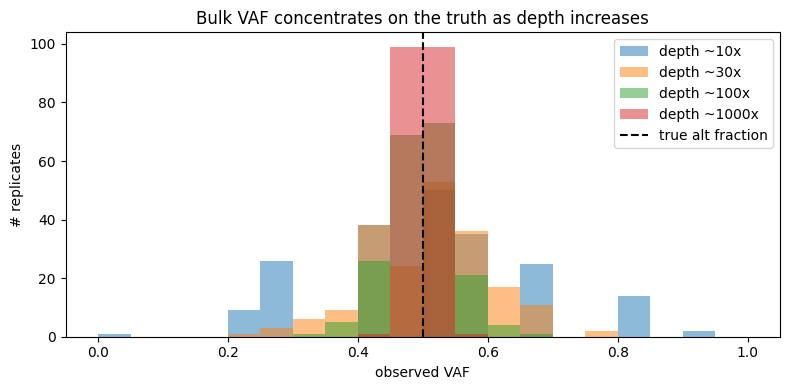

In [5]:
het_locus = genes[het_dip]
depths = [10, 30, 100, 1000]
fig, ax = plt.subplots(figsize=(8, 4))
for d in depths:
    vafs = [bulkDNA(breadth="wgs", seed=s, target_genes=[het_locus], mu_depth=float(d),
                    error_rate=0.005).run(cell_data).observed_data.loc[het_locus, "vaf"]
            for s in range(200)]
    ax.hist(vafs, bins=20, range=(0, 1), alpha=0.5, label=f"depth ~{d}x")
ax.axvline(0.5, color="k", ls="--", label="true alt fraction")
ax.set_xlabel("observed VAF"); ax.set_ylabel("# replicates")
ax.set_title("Bulk VAF concentrates on the truth as depth increases"); ax.legend()
plt.tight_layout(); plt.show()

## 5. Single-cell: lumpy amplification + ADO

Single-cell DNA is the same core in a different regime. **(a)** Per-cell whole-genome amplification
makes coverage *lumpy* — small $\kappa$ gives wildly uneven coverage even though it still tracks CN
on average. **(b)** **Allelic dropout (ADO)** — the dominant single-cell artifact — randomly loses one
allele at heterozygous loci, so a true-0.5 locus is *observed* as homozygous (VAF→0 or 1).

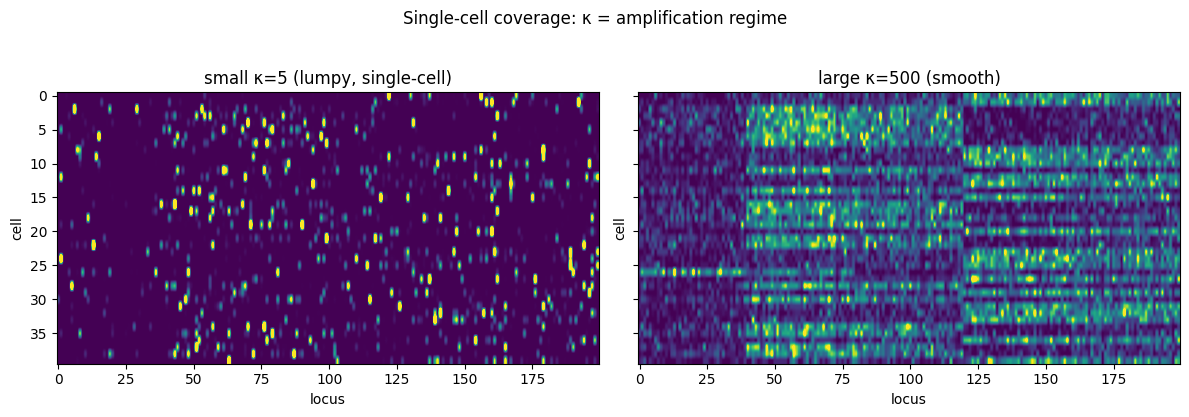

single-cell mean coverage by segment (tracks CN):
0     2.8
1     9.5
2     7.2
3    13.2
4    12.4
dtype: float64


In [6]:
# (a) coverage lumpiness: small kappa (single-cell) vs large kappa (bulk-like)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)
for ax, kappa, name in zip(axes, [5.0, 500.0], ["small κ=5 (lumpy, single-cell)", "large κ=500 (smooth)"]):
    scr = scDNA(n_cells=40, breadth="wgs", seed=2, kappa=kappa).run(cell_data)
    cov = scr.coverage.values
    ax.imshow(cov, aspect="auto", cmap="viridis", vmax=np.percentile(cov, 98))
    ax.set_title(name); ax.set_xlabel("locus"); ax.set_ylabel("cell")
fig.suptitle("Single-cell coverage: κ = amplification regime", y=1.03)
plt.tight_layout(); plt.show()

# coverage still tracks CN on average (per-cell DM driven by that cell's copy number)
scr = scDNA(n_cells=60, breadth="wgs", seed=2).run(cell_data)
seg_cov = pd.DataFrame(scr.coverage.values, columns=[int(g.split('_')[1]) for g in scr.genes])
print("single-cell mean coverage by segment (tracks CN):")
print(seg_cov.T.groupby(level=0).mean().mean(axis=1).round(1))

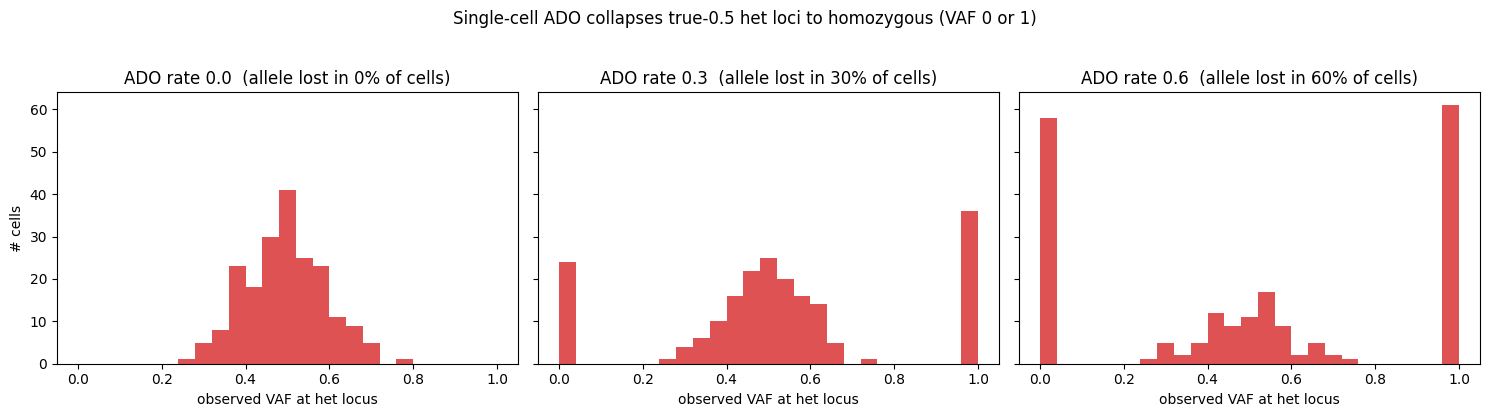

In [7]:
# (b) ADO -> allele loss at a heterozygous locus
het_locus = genes[het_dip]
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, ado in zip(axes, [0.0, 0.3, 0.6]):
    scr = scDNA(n_cells=200, breadth="panel", seed=4, ado_rate=ado,
                target_genes=[het_locus], mu_depth=200.0).run(cell_data)
    vaf = scr.vaf[het_locus].values
    ax.hist(vaf, bins=25, range=(0, 1), color="C3", alpha=0.8)
    lost = scr.ado_mask[het_locus].mean()
    ax.set_title(f"ADO rate {ado}  (allele lost in {lost:.0%} of cells)")
    ax.set_xlabel("observed VAF at het locus")
axes[0].set_ylabel("# cells")
fig.suptitle("Single-cell ADO collapses true-0.5 het loci to homozygous (VAF 0 or 1)", y=1.03)
plt.tight_layout(); plt.show()

## 6. Breadth behaves: panel = deep / few loci, WGS = shallow / many

Summarising the orthogonal **capture-breadth** axis for both modalities — the trade-off behind
"panel = deep VAF on few drivers but poor genome-wide CNA; WGS = good CNA, shallow VAF".

In [8]:
rows = []
for mode, ctor in [("bulk", lambda br: bulkDNA(breadth=br, seed=1)),
                   ("single-cell", lambda br: scDNA(n_cells=40, breadth=br, seed=1))]:
    for br in ["wgs", "wes", "panel"]:
        r = ctor(br).run(cell_data)
        cov = r.observed_data["coverage"] if mode == "bulk" else r.coverage.values
        n_loci = len(r.observed_data) if mode == "bulk" else r.coverage.shape[1]
        rows.append(dict(mode=mode, breadth=br, n_loci=n_loci,
                         mean_depth=round(float(np.mean(cov)), 1)))
pd.DataFrame(rows)

,mode,breadth,n_loci,mean_depth
0,bulk,wgs,200,30.0
1,bulk,wes,60,120.0
2,bulk,panel,30,1500.0
3,single-cell,wgs,200,9.0
4,single-cell,wes,60,36.0
5,single-cell,panel,30,450.0


## 7. Multi-batch — same biology, different technical signature

Two `DNABatch` realizations with the same hyper-parameters but different seeds give two batches:
identical biological ground truth, different per-batch GC curve / depth shift / capture draws.
The known cell↔cell (or locus↔locus) correspondence makes this a labelled benchmark for
panel-of-normals normalization / batch correction — `run_dna_batches` builds it.

same biology: true_cn identical = True


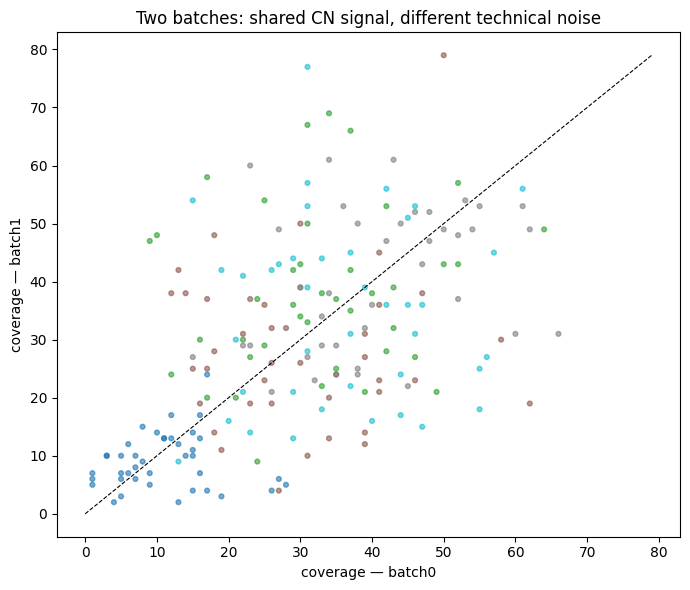

In [9]:
assays = run_dna_batches(cell_data, mode="bulk", n_batches=2, base_seed=42, breadth="wgs")
a, b = assays
print("same biology:",
      "true_cn identical =", np.allclose(a.observed_data.true_cn, b.observed_data.true_cn))
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(a.observed_data["coverage"], b.observed_data["coverage"], s=12, alpha=0.6,
           c=a.observed_data["segment"], cmap="tab10")
lim = [0, max(a.observed_data.coverage.max(), b.observed_data.coverage.max())]
ax.plot(lim, lim, "k--", lw=0.8)
ax.set_xlabel(f"coverage — {a.batch.label}"); ax.set_ylabel(f"coverage — {b.batch.label}")
ax.set_title("Two batches: shared CN signal, different technical noise")
plt.tight_layout(); plt.show()

## Summary

* **Coverage tracks copy number** (bulk + single-cell), via a copy-number-driven
  Dirichlet-Multinomial depth model; the CNA log2-ratio profile is the caller input.
* At a **fixed read budget** a large amplicon **compositionally steals** reads from the rest —
  depth is *relative*, not absolute.
* **VAF recovers the true alt fraction** at high depth (Binomial allele layer).
* Single-cell adds **lumpy amplification** (small $\kappa$) and **ADO** (allele loss at het loci),
  the dominant single-cell artifact, as a separate Bernoulli layer.
* **Capture breadth** (WGS / WES / panel) trades locus count against depth identically for both
  modalities.

**M4 `estimate()` targets** named in this model: $\kappa$ (amplification regime), the per-target /
per-amplicon capture efficiencies (`capture_sigma`), the **ADO rate**, the Beta-Binomial
concentration, the GC-curve parameters, and the sequencing `error_rate`.